<a href="https://colab.research.google.com/github/CodeWithradhika/CSET343./blob/main/Assignment%204.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

import warnings
warnings.filterwarnings("ignore")

In [2]:
# Load Breast Cancer Wisconsin dataset

data = load_breast_cancer()

# Create DataFrame
X = pd.DataFrame(data.data, columns=data.feature_names)

# Create target column
y = pd.Series(data.target, name="Outcome")

# Display first 5 rows
X.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
# Combine features and target

df = X.copy()
df["Outcome"] = y

# Display first 5 rows
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,Outcome
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [4]:
# Dataset shape

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 569
Number of columns: 31


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [6]:
print(df.columns.tolist())

['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension', 'Outcome']


In [7]:
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,Outcome
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [8]:
df.drop("Outcome" , axis=1).mean()

,0
mean radius,14.127292
mean texture,19.289649
mean perimeter,91.969033
mean area,654.889104
mean smoothness,0.096360
mean compactness,0.104341
mean concavity,0.088799
mean concave points,0.048919
mean symmetry,0.181162
mean fractal dimension,0.062798


In [10]:
df.drop("Outcome", axis=1).median()

,0
mean radius,13.370000
mean texture,18.840000
mean perimeter,86.240000
mean area,551.100000
mean smoothness,0.095870
mean compactness,0.092630
mean concavity,0.061540
mean concave points,0.033500
mean symmetry,0.179200
mean fractal dimension,0.061540


In [11]:
df.drop("Outcome", axis=1).std()

,0
mean radius,3.524049
mean texture,4.301036
mean perimeter,24.298981
mean area,351.914129
mean smoothness,0.014064
mean compactness,0.052813
mean concavity,0.079720
mean concave points,0.038803
mean symmetry,0.027414
mean fractal dimension,0.007060


In [12]:
print("Missing value in each column:")
print(df.isnull().sum())

Missing value in each column:
mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
Outcome                    0
dtype: int64


In [13]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [14]:
df = df.drop_duplicates()
print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (569, 31)


In [15]:
# Calculate outliers using IQR

Q1 = df.drop("Outcome", axis=1).quantile(0.25)
Q3 = df.drop("Outcome", axis=1).quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = (
    (df.drop("Outcome", axis=1) < lower_bound) |
    (df.drop("Outcome", axis=1) > upper_bound)
)

print("Number of outliers in each feature:")
print(outliers.sum())

Number of outliers in each feature:
mean radius                14
mean texture                7
mean perimeter             13
mean area                  25
mean smoothness             6
mean compactness           16
mean concavity             18
mean concave points        10
mean symmetry              15
mean fractal dimension     15
radius error               38
texture error              20
perimeter error            38
area error                 65
smoothness error           30
compactness error          28
concavity error            22
concave points error       19
symmetry error             27
fractal dimension error    28
worst radius               17
worst texture               5
worst perimeter            15
worst area                 35
worst smoothness            7
worst compactness          16
worst concavity            12
worst concave points        0
worst symmetry             23
worst fractal dimension    24
dtype: int64


In [16]:
print("Total outlier values:", outliers.sum().sum())

Total outlier values: 608


In [17]:
# Create a copy

df_clean = df.copy()

# Cap outliers using IQR limits

for column in df_clean.drop("Outcome", axis=1).columns:

    Q1 = df_clean[column].quantile(0.25)
    Q3 = df_clean[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_clean[column] = df_clean[column].clip(lower, upper)

print("Outliers handled using IQR capping.")

Outliers handled using IQR capping.


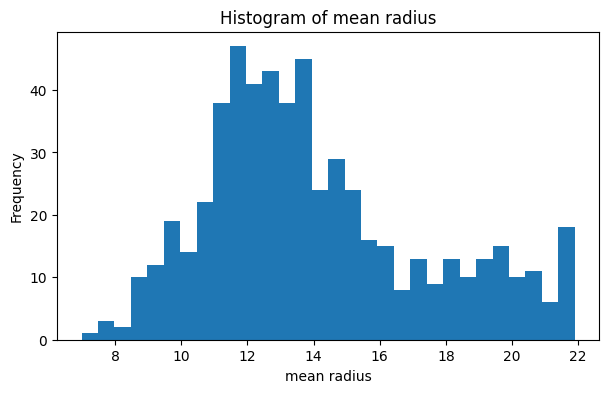

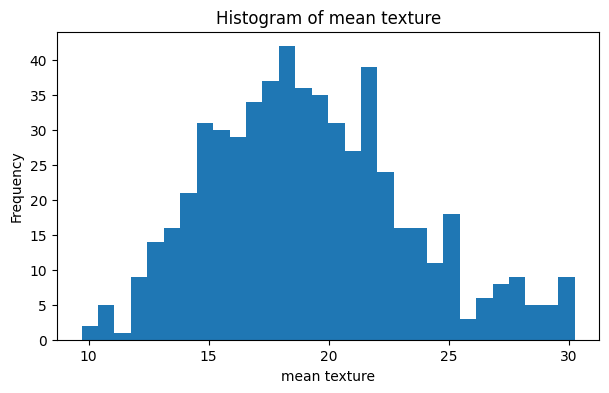

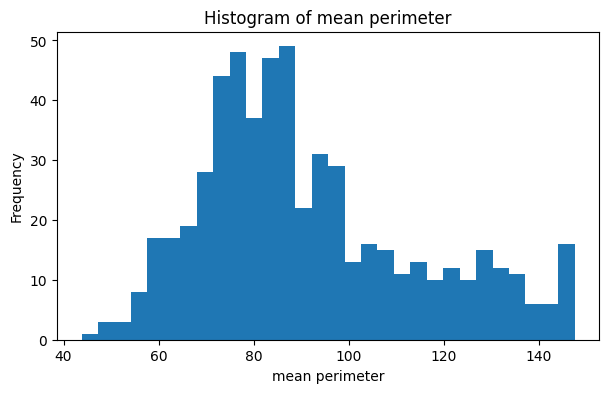

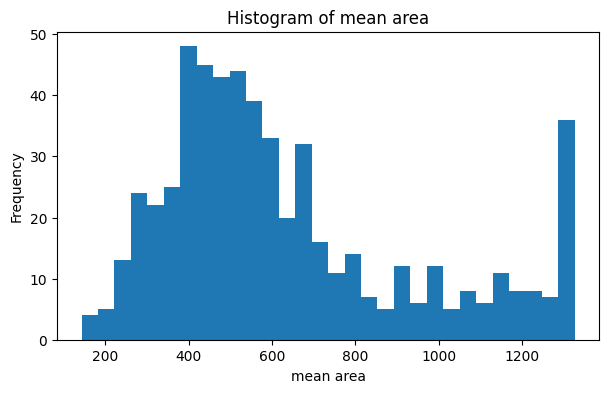

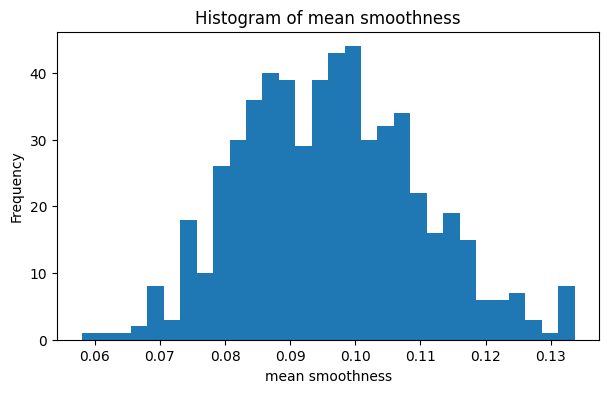

In [18]:
# Histograms for selected features

features_to_plot = [
    "mean radius",
    "mean texture",
    "mean perimeter",
    "mean area",
    "mean smoothness"
]

for feature in features_to_plot:
    plt.figure(figsize=(7, 4))
    plt.hist(df_clean[feature], bins=30)
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.title("Histogram of " + feature)
    plt.show()

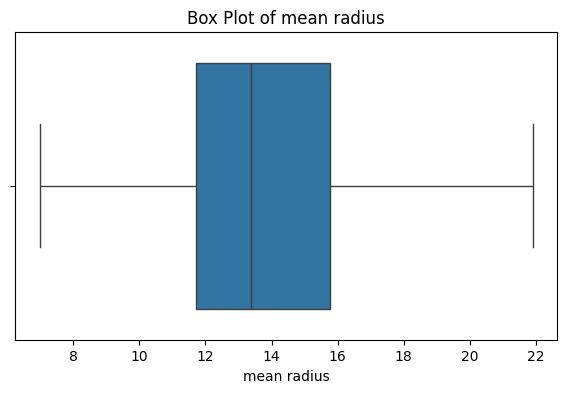

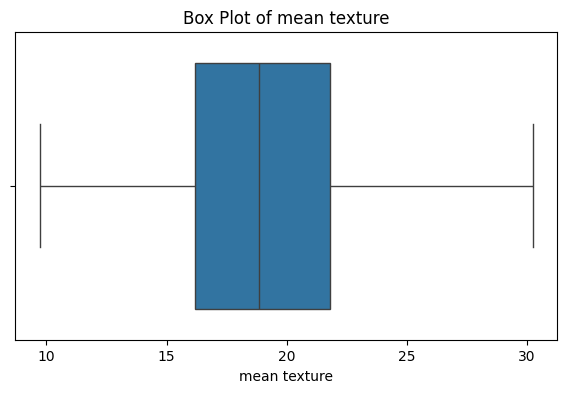

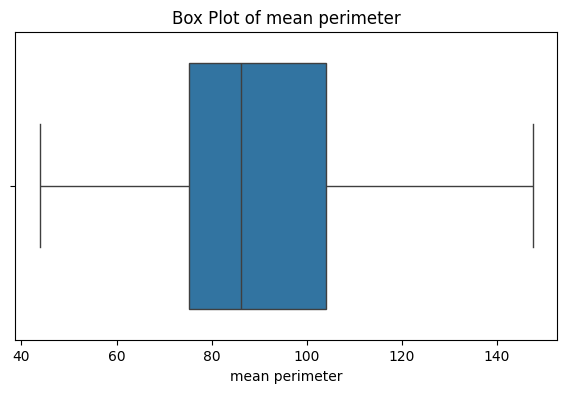

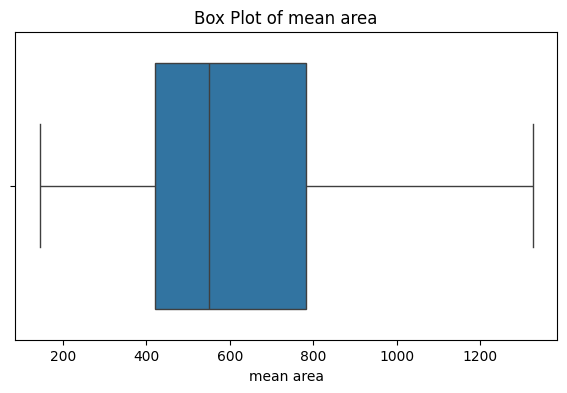

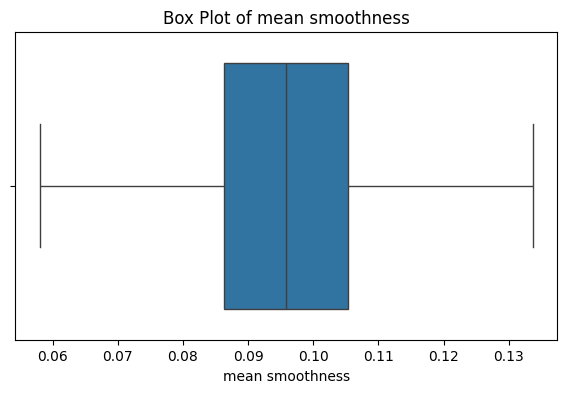

In [19]:
# Box plots for selected features

for feature in features_to_plot:
    plt.figure(figsize=(7, 4))
    sns.boxplot(x=df_clean[feature])
    plt.title("Box Plot of " + feature)
    plt.xlabel(feature)
    plt.show()

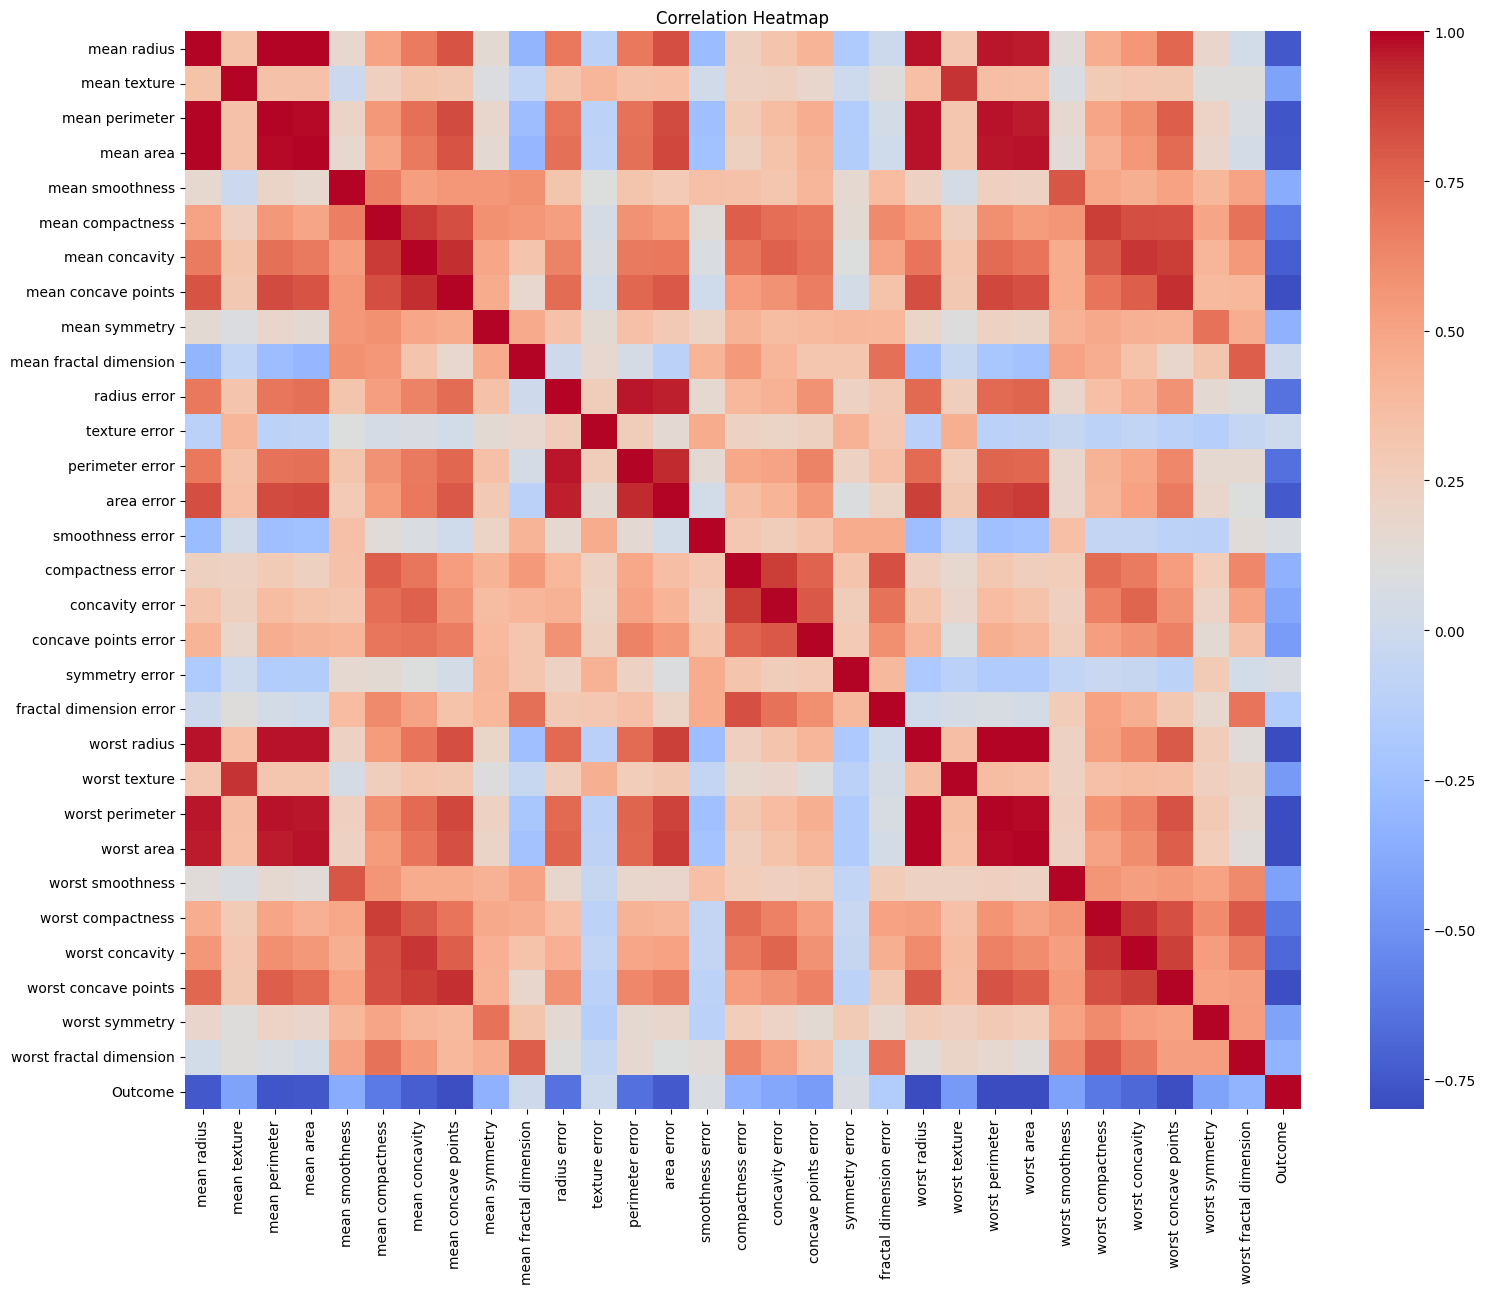

In [20]:
# Calculate correlation matrix

correlation_matrix = df_clean.corr()

# Plot heatmap

plt.figure(figsize=(18, 14))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    annot=False
)

plt.title("Correlation Heatmap")
plt.show()

In [21]:
# Count target classes

print(df_clean["Outcome"].value_counts())

Outcome
1    357
0    212
Name: count, dtype: int64


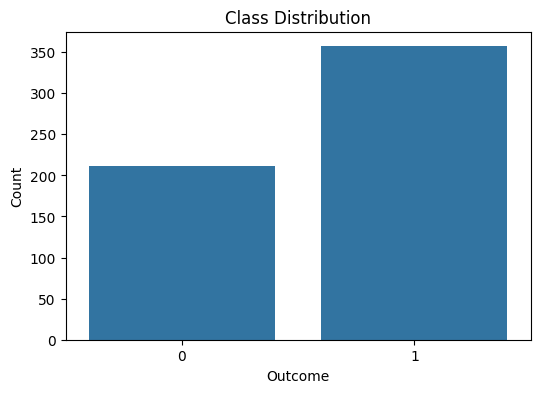

In [22]:
# Plot class distribution

plt.figure(figsize=(6, 4))

sns.countplot(x="Outcome", data=df_clean)

plt.title("Class Distribution")
plt.xlabel("Outcome")
plt.ylabel("Count")

plt.show()

In [23]:
# Check original target names

print(data.target_names)

['malignant' 'benign']


In [24]:
# Convert target:
# Malignant = 1
# Benign = 0

df_clean["Outcome"] = df_clean["Outcome"].map({
    0: 1,
    1: 0
})

print(df_clean["Outcome"].value_counts())

Outcome
0    357
1    212
Name: count, dtype: int64


In [25]:
# Calculate percentage of each class

class_percentage = df_clean["Outcome"].value_counts(normalize=True) * 100

print(class_percentage)

Outcome
0    62.741652
1    37.258348
Name: proportion, dtype: float64


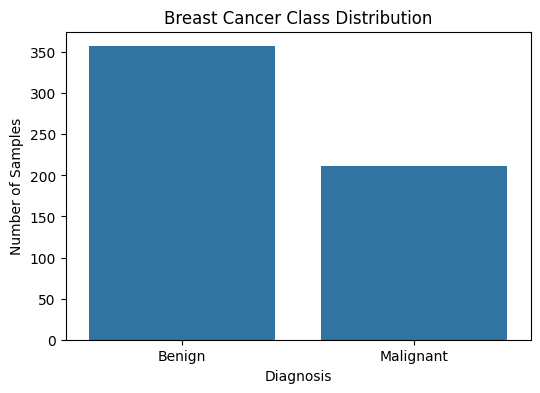

In [26]:
# Plot class distribution with labels

plt.figure(figsize=(6, 4))

sns.countplot(x="Outcome", data=df_clean)

plt.xticks(
    [0, 1],
    ["Benign", "Malignant"]
)

plt.xlabel("Diagnosis")
plt.ylabel("Number of Samples")
plt.title("Breast Cancer Class Distribution")

plt.show()

In [27]:
# Separate independent variables and target variable

X = df_clean.drop("Outcome", axis=1)

y = df_clean["Outcome"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (569, 30)
y shape: (569,)


In [28]:
# Split dataset into training and testing sets
# 80% training and 20% testing
# Stratify maintains class distribution

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 455
Testing samples: 114


In [29]:
print("Training class distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting class distribution:")
print(y_test.value_counts(normalize=True) * 100)

Training class distribution:
Outcome
0    62.637363
1    37.362637
Name: proportion, dtype: float64

Testing class distribution:
Outcome
0    63.157895
1    36.842105
Name: proportion, dtype: float64


In [30]:
# Create StandardScaler

scaler = StandardScaler()

# Fit scaler only on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data
X_test_scaled = scaler.transform(X_test)

print("Feature standardization completed.")

Feature standardization completed.


In [31]:
# Create Logistic Regression model

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train the model

logistic_model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [32]:
# Predict test data

y_pred = logistic_model.predict(X_test_scaled)

# Get probability predictions
y_prob = logistic_model.predict_proba(X_test_scaled)[:, 1]

print("Predicted classes:")
print(y_pred[:20])

print("\nPredicted probabilities:")
print(y_prob[:20])

Predicted classes:
[0 1 0 0 1 0 1 0 0 0 1 0 1 0 0 0 0 0 0 0]

Predicted probabilities:
[1.94610313e-04 9.99999992e-01 2.52056945e-02 4.73203656e-01
 5.32268433e-01 6.62916322e-04 8.03317000e-01 4.41823369e-04
 3.47997507e-04 7.38115918e-03 9.24419681e-01 6.01013438e-05
 9.99999983e-01 3.86105227e-03 5.40606459e-03 5.29426261e-07
 5.14132595e-02 1.46302166e-04 2.26089617e-01 1.31811732e-05]


In [33]:
# Calculate accuracy

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

Accuracy: 0.9649122807017544
Accuracy (%): 96.49122807017544


In [34]:
# Calculate metrics

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Precision: 0.975
Recall: 0.9285714285714286
F1 Score: 0.9512195121951219


In [35]:
# Classification report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Benign", "Malignant"]
    )
)

              precision    recall  f1-score   support

      Benign       0.96      0.99      0.97        72
   Malignant       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



In [36]:
# Calculate confusion matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[71  1]
 [ 3 39]]


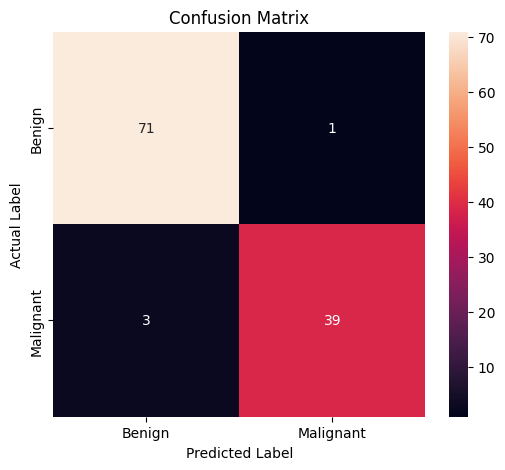

In [37]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Benign", "Malignant"],
    yticklabels=["Benign", "Malignant"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")

plt.show()

In [38]:
# Extract confusion matrix values

TN, FP, FN, TP = cm.ravel()

print("True Negative (TN):", TN)
print("False Positive (FP):", FP)
print("False Negative (FN):", FN)
print("True Positive (TP):", TP)

True Negative (TN): 71
False Positive (FP): 1
False Negative (FN): 3
True Positive (TP): 39


In [39]:
# Calculate False Positive Rate and True Positive Rate

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

# Calculate AUC

auc_score = roc_auc_score(
    y_test,
    y_prob
)

print("AUC Score:", auc_score)

AUC Score: 0.9963624338624338


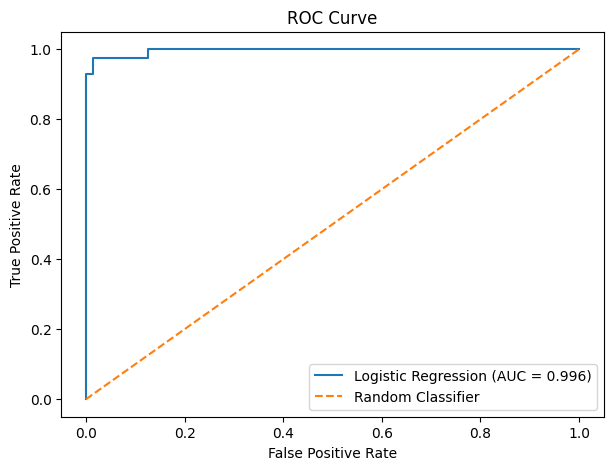

In [40]:
plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {auc_score:.3f})"
)

# Random classifier line

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()

In [41]:
# Create evaluation summary

results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "AUC"
    ],

    "Score": [
        accuracy,
        precision,
        recall,
        f1,
        auc_score
    ]
})

results

,Metric,Score
0,Accuracy,0.964912
1,Precision,0.975000
2,Recall,0.928571
3,F1 Score,0.951220
4,AUC,0.996362
